## OptimESM: NEMO Pipeline Regionalisation Diagnostics

In [1]:
import glob
import xarray as xr
from nemo_cookbook import NEMODataTree
import matplotlib.pyplot as plt

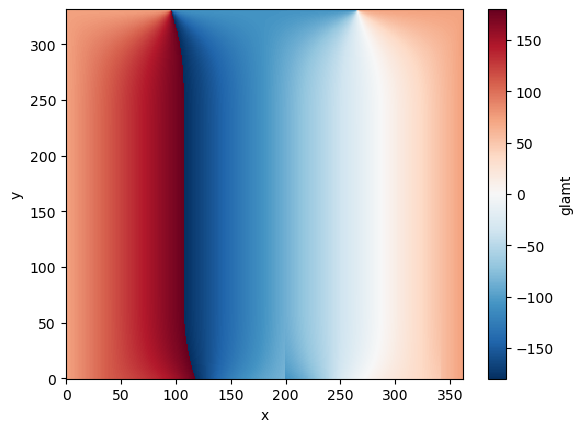

In [3]:
fpath = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/IPSL-CM6-ESMCO2/Ofx/eORCA1.2_mesh_mask_IPSL.nc"
ds_domain = xr.open_dataset(fpath).rename({"z": "nav_lev"}).squeeze()
ds_domain.glamt.plot()

### IPSL-CM6-ESMCO2 - Regional Mixed Layer Diagnostics

In [ ]:
# Define path to domain_cfg:
fpath = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/IPSL-CM6-ESMCO2/Ofx/eORCA1.2_mesh_mask_IPSL.nc"
ds_domain = xr.open_dataset(fpath).rename({"z": "nav_lev"}).squeeze()

# Define path to eORCA1 monthly mean outputs:
exp_id="r1i1p3f1"
exp_name="esm-hist"
realm_name="Omon"
variable_name="thetao"
fdir = f"/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/IPSL-CM6-ESMCO2/{exp_name}/{exp_id}/{realm_name}"
fpaths_gridT=f"{fdir}/{variable_name}/gn/v*/{variable_name}_{realm_name}_IPSL-CM6-ESMCO2_{exp_name}_{exp_id}_gn_*.nc"

# Define CFDatetimeCoder to decode time coords:
coder = xr.coders.CFDatetimeCoder(time_unit="s")
ds_gridT = xr.open_mfdataset(fpaths_gridT,
                             data_vars="minimal",
                             compat="no_conflicts",
                             decode_times=coder,
                             parallel=False,
                             engine="netcdf4"
                            )

ds_gridT = ds_gridT.rename({"i": "x",
                            "j": "y",
                            "lev": "deptht",
                             "time": "time_counter"
                              })

ds_gridT

In [ ]:
variable_name="umo"
fpaths_gridU=f"{fdir}/{variable_name}/gn/v*/{variable_name}_{realm_name}_IPSL-CM6-ESMCO2_{exp_name}_{exp_id}_gn_*.nc"

# Define CFDatetimeCoder to decode time coords:
coder = xr.coders.CFDatetimeCoder(time_unit="s")
ds_gridU = xr.open_mfdataset(fpaths_gridU,
                             data_vars="minimal",
                             compat="no_conflicts",
                             decode_times=coder,
                             parallel=False,
                             engine="netcdf4"
                            )

ds_gridU = ds_gridU.rename({"i": "x",
                            "j": "y",
                            "lev": "depthu",
                             "time": "time_counter"
                              })

ds_gridU

In [ ]:
variable_name="vmo"
fpaths_gridV=f"{fdir}/{variable_name}/gn/v*/{variable_name}_{realm_name}_IPSL-CM6-ESMCO2_{exp_name}_{exp_id}_gn_*.nc"

# Define CFDatetimeCoder to decode time coords:
coder = xr.coders.CFDatetimeCoder(time_unit="s")
ds_gridV = xr.open_mfdataset(fpaths_gridV,
                             data_vars="minimal",
                             compat="no_conflicts",
                             decode_times=coder,
                             parallel=False,
                             engine="netcdf4"
                            )

ds_gridV = ds_gridV.rename({"i": "x",
                            "j": "y",
                            "lev": "depthv",
                             "time": "time_counter"
                              })

ds_gridV

In [ ]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
# Note: domain_cfg z-dimension is expected to be named 'nav_lev'.
datasets = {"parent":
            {"domain": ds_domain,
             "gridT": ds_gridT,
             "gridU": ds_gridU,
             "gridV": ds_gridV,
             }
            }

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

In [ ]:
import numpy as np
from skimage import measure
from nemo_cookbook.masks import create_polygon_mask

i_poly = np.array([226, 226, 230, 245, 257, 266, 277, 281, 285, 285, 285, 233, 226]) + 0.5
j_poly = np.array([275, 286, 291, 291, 289, 282, 278, 270, 262, 255, 255, 255, 275]) + 1 + 0.5

mask = create_polygon_mask(lon_grid=nemo['gridT']['i'].expand_dims(dim={"j": nemo['gridT']['j'].size}, axis=0),
                           lat_grid=nemo['gridT']['j'].expand_dims(dim={"i": nemo['gridT']['i'].size}, axis=1),
                           lon_poly=i_poly,
                           lat_poly=j_poly,
                           dims=('j', 'i')
                           )

mask_data = mask.astype('int').values
boundary = measure.find_contours(image=mask_data, level=0.5)

In [ ]:
# Plot:
da_mlotst = nemo['gridT']['thetao'].isel(k=0).where(nemo['gridT']['tmaskutil'])
da_mlotst.isel(time_counter=2).where(mask).plot(xlim=[200, 300], ylim=[230, 331])

plt.plot([bdy[1] for bdy in boundary[0]], [bdy[0] for bdy in boundary[0]], color='coral')

In [ ]:
i_poly = np.array([bdy[1] for bdy in boundary[0]][-55:-12])
j_poly = np.array([bdy[0] for bdy in boundary[0]][-55:-12])
i_poly = np.concatenate([i_poly, np.array([263, 280, 294, 294, 281])]) + 0.5
j_poly = np.concatenate([j_poly + 0.5, np.array([310, 310, 299, 278, 270]) + 1]) + 0.5

mask_GIN = create_polygon_mask(lon_grid=nemo['gridT']['i'].expand_dims(dim={"j": nemo['gridT']['j'].size}, axis=0),
                           lat_grid=nemo['gridT']['j'].expand_dims(dim={"i": nemo['gridT']['i'].size}, axis=1),
                           lon_poly=i_poly,
                           lat_poly=j_poly,
                           dims=('j', 'i')
                           )

mask_GIN_data = mask_GIN.astype('int').values
boundary_GIN = measure.find_contours(image=mask_GIN_data, level=0.5)

In [ ]:
# Plot:
da_mlotst.isel(time_counter=2).where((mask)).plot(xlim=[200, 300], ylim=[230, 331], cmap='viridis') # .where(mask | mask_GIN)
da_mlotst.isel(time_counter=2).where((mask_GIN)).plot(xlim=[200, 300], ylim=[230, 331], cmap='RdBu_r') # .where(mask | mask_GIN)

plt.plot([bdy[1] for bdy in boundary[0]], [bdy[0] for bdy in boundary[0]], color='pink')
plt.plot([bdy[1] for bdy in boundary_GIN[0]], [bdy[0] for bdy in boundary_GIN[0]], color='coral')

i = np.array([bdy[1] for bdy in boundary[0]][-55:-12])
j = np.array([bdy[0] for bdy in boundary[0]][-55:-12])
i = np.concatenate([i, np.array([263, 280, 294, 294, 281])])
j = np.concatenate([j, np.array([310, 310, 299, 278, 270])])

In [ ]:
(mask.astype(int) + mask_GIN.astype(int)).plot()


In [ ]:
# Plot:
da_mlotst.isel(time_counter=2).plot(ylim=[230, 335])

# plt.plot([bdy[1] for bdy in boundary[0]], [bdy[0] for bdy in boundary[0]], color='pink')
# plt.plot([bdy[1] for bdy in boundary_GIN[0]][-30:], [bdy[0] for bdy in boundary_GIN[0]][-30:], color='coral')
# plt.plot([bdy[1] for bdy in boundary_GIN[0]][:41], [bdy[0] for bdy in boundary_GIN[0]][:41], color='coral')
# plt.plot([230, 230, 200, 200, 330, 330], [291, 306, 306, 331, 331, 295], lw=2, color='pink')
# plt.plot([40, 158, 158, 40, 40], [285, 285, 331, 331, 285], lw=2, color='pink')

i = np.concatenate([np.array([230, 230, 200, 200, 330, 330]),
                    np.array([bdy[1] for bdy in boundary_GIN[0]][-30:]),
                    np.array([bdy[1] for bdy in boundary_GIN[0]][:44]),
                    np.array([245, 230])])
j = np.concatenate([np.array([291, 306, 306, 332, 332, 295]),
                    np.array([bdy[0] for bdy in boundary_GIN[0]][-30:]),
                    np.array([bdy[0] for bdy in boundary_GIN[0]][:44]),
                    np.array([291, 291])])

plt.plot(i, j, color='pink')


In [ ]:
i_poly = np.concatenate([np.array([230, 230, 200, 200, 330, 330]),
                    np.array([bdy[1] for bdy in boundary_GIN[0]][-30:]),
                    np.array([bdy[1] for bdy in boundary_GIN[0]][:43]),
                    np.array([245, 230])]) + 0.5

j_poly = np.concatenate([np.array([291, 306, 306, 332, 332, 295]),
                    np.array([bdy[0] for bdy in boundary_GIN[0]][-30:]) + 0.5,
                    np.array([bdy[0] for bdy in boundary_GIN[0]][:43]) + 0.5,
                    np.array([292, 292])]) + 0.5

mask_AO = create_polygon_mask(lon_grid=nemo['gridT']['i'].expand_dims(dim={"j": nemo['gridT']['j'].size}, axis=0),
                              lat_grid=nemo['gridT']['j'].expand_dims(dim={"i": nemo['gridT']['i'].size}, axis=1),
                              lon_poly=i_poly,
                              lat_poly=j_poly,
                              dims=('j', 'i')
                             )

mask_AO_data = mask_AO.astype('int').values
boundary_AO = measure.find_contours(image=mask_AO_data, level=0.5)

In [ ]:
mask_AO_LHS = create_polygon_mask(lon_grid=nemo['gridT']['i'].expand_dims(dim={"j": nemo['gridT']['j'].size}, axis=0),
                                  lat_grid=nemo['gridT']['j'].expand_dims(dim={"i": nemo['gridT']['i'].size}, axis=1),
                                  lon_poly=[40, 158, 158, 40, 40],
                                  lat_poly=[285, 285, 332, 332, 285],
                                  dims=('j', 'i')
                                 )

In [ ]:
mask_AO_complete = mask_AO | mask_AO_LHS

In [ ]:
(mask_AO_complete.astype(int) + mask_GIN.astype(int) + mask.astype(int)).plot()

In [ ]:
# -- Plotting -- #
mask_AO_complete.where(mask_AO_complete).plot(ylim=[230, 333], cmap='Greens')
mask.where(mask).plot(ylim=[230, 333], cmap='Reds')
mask_GIN.where(mask_GIN).plot(ylim=[230, 333], cmap='Blues')

plt.plot([bdy[1] for bdy in boundary[0]], [bdy[0] for bdy in boundary[0]], color='0.1')
plt.plot([bdy[1] for bdy in boundary_GIN[0]], [bdy[0] for bdy in boundary_GIN[0]], color='0.1')
plt.plot([bdy[1] for bdy in boundary_AO[0]], [bdy[0] for bdy in boundary_AO[0]], color='0.1')
plt.plot([40, 158, 158, 40, 40], [285, 285, 332, 332, 285], lw=2, color='0.1')


In [ ]:
da_mlotst.isel(time_counter=2).where(mask_AO_complete).plot(ylim=[230, 335])

plt.plot([bdy[1] for bdy in boundary_AO[0]], [bdy[0] for bdy in boundary_AO[0]], color='coral')
plt.plot([40, 158, 158, 40, 40], [285, 285, 332, 332, 285], lw=2, color='pink')

In [ ]:
# Plot:
plt.figure(figsize=(12, 5))
da_mlotst.isel(time_counter=2).where(mask).plot(xlim=[0, 360], ylim=[230, 331], cmap='viridis')
da_mlotst.isel(time_counter=2).where(mask_GIN).plot(xlim=[0, 360], ylim=[230, 331], cmap='RdBu_r')
da_mlotst.isel(time_counter=2).where(mask_AO_complete).plot(xlim=[0, 360], ylim=[230, 331], cmap='cividis_r')

# plt.plot([bdy[1] for bdy in boundary[0]], [bdy[0] for bdy in boundary[0]], color='pink')
# plt.plot([bdy[1] for bdy in boundary_GIN[0]], [bdy[0] for bdy in boundary_GIN[0]], color='coral')
# plt.plot([bdy[1] for bdy in boundary_AO[0]], [bdy[0] for bdy in boundary_AO[0]], color='coral')


## Test Regional Masks:

In [ ]:
ds_mask = xr.open_dataset("/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/IPSL-CM6-ESMCO2/Ofx/regional_masks_Ofx_IPSL-CM6-ESMCO2.nc")
ds_mask

In [ ]:
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['aomsk']).plot(cmap='viridis')
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['spnamsk']).plot()
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['ginmsk']).plot(cmap='cividis')

In [ ]:
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['aomsk_oo']).plot(cmap='viridis')
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['spnamsk_oo']).plot()
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['ginmsk_oo']).plot(cmap='cividis')

In [ ]:
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['aomsk_ss']).plot(cmap='viridis')
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['spnamsk_ss']).plot()
nemo['gridT/thetao'].isel(k=0, time_counter=0).where(nemo['gridT/tmaskutil'] & ds_mask['ginmsk_ss']).plot(cmap='cividis')